# Naming sanitization
Notebook to sanitize all names for packages, rasters, etc.

## Modules

In [1]:
import os
import pandas as pd
import geopandas as gpd
import pyogrio
import numpy as np

In [2]:
geom_layer = "geometry_layer"

rename_cols = {
    'cf': 'leaf', 
    'cf_median': 'leaf_median', 
    'cf_std': 'leaf_std', 
}

rename_metrics = {
    'cf_mean': 'leaf_mean', 
    'cf_median': 'leaf_median', 
    'cf_std': 'leaf_std', 
}

In [3]:
def inspect_gpkg(filepath: str):
    layer_info = pyogrio.list_layers(filepath)  # array of [name, geom_type]

    for name, geom_type in layer_info:
        if geom_type is None:
            # non-spatial table -> read without geometry
            df = gpd.read_file(filepath, layer=name, ignore_geometry=True)
            print(f"{name}: TABLE, shape={df.shape}, columns={list(df.columns)}")
        else:
            gdf = gpd.read_file(filepath, layer=name)
            print(f"{name}: {gdf.shape}, CRS={gdf.crs}, geom={gdf.geom_type.unique()}, geom_type_reported={geom_type}")

In [4]:
def load_gpkg(filepath: str):
    layer_info = pyogrio.list_layers(filepath)
    
    data = {}
    
    for name, geom_type in layer_info:
        if geom_type is None:
            df = gpd.read_file(filepath, layer=name, ignore_geometry=True)
        else:
            df = gpd.read_file(filepath, layer=name)
        data[name] = df
    
    return data

In [5]:
def update_gpkg_to_disk(data: gpd.GeoDataFrame, gpkg_path: str):
    # Previously this used mode="w" only for the first layer and mode="a"
    # (append) for every other layer. For GPKG, "append" adds rows to a
    # layer that already exists instead of replacing it -- so re-running
    # this notebook against an already-populated file duplicated every row
    # in the data tables (leaf/leaf_median/leaf_std, etc.) on each save,
    # including rows that had just been set to np.nan. The old, un-fixed
    # duplicate rows stuck around forever and kept re-attaching to the
    # geometry on every merge, which is why manually nulling out
    # Antarctica/Tundra values never stuck across runs.
    # Deleting the file first and writing every layer fresh guarantees no
    # duplication, regardless of the driver's append semantics.
    if os.path.exists(gpkg_path):
        os.remove(gpkg_path)

    for name, df in data.items():
        if isinstance(df, gpd.GeoDataFrame):
            df.to_file(gpkg_path, layer=name, driver="GPKG", mode="w")
        else:
            # non-spatial table: needs pyogrio directly since to_file expects geometry
            pyogrio.write_dataframe(df, gpkg_path, layer=name, driver="GPKG", append=False)

    print(f'Geopackage updated into: {gpkg_path}')

### Repair pass

`update_gpkg_to_disk` above used to save every layer after the first with GDAL's "append" mode, which adds rows to a layer that already exists instead of replacing it. Re-running this notebook against an already-populated `.gpkg` therefore duplicated rows on every save (including ones that had just been set to `np.nan`), and the stale, un-fixed duplicates never went away — that's why the Antarctica/Tundra values kept coming back no matter how many times they were nulled out. This has been fixed above (every save now deletes and rewrites the file), but any `.gpkg` already corrupted by the old behavior still has the duplicate rows sitting in it. Run the repair pass below once (safe to re-run; it's a no-op once a file is clean) before trusting any of the outputs.

In [6]:
import sys
sys.path.insert(0, "../src")
from sbtn_leaf.gpkg_repair import repair_gpkg

gpkg_paths_to_repair = [
    "../LEAFs/acidification/acidification_ecoregion.gpkg",
    "../LEAFs/acidification/acidification_subcountry.gpkg",
    "../LEAFs/acidification/acidification_country.gpkg",
    "../LEAFs/soil_erosion/se_ecoregions_clipped_2.gpkg",
    "../LEAFs/soil_erosion/soil_erosion_subcountry.gpkg",
    "../LEAFs/soil_erosion/soil_erosion_country.gpkg",
]

for path in gpkg_paths_to_repair:
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        print(f"[SKIP] {path}: not found")
        continue
    removed = repair_gpkg(path)
    total = sum(removed.values())
    if total:
        print(f"[FIX]  {path}: removed {total} duplicate rows ({removed})")
    else:
        print(f"[OK]   {path}: no duplicates found")

Could not determine dtype for column 1, falling back to string


[OK]   ../LEAFs/acidification/acidification_ecoregion.gpkg: no duplicates found
[OK]   ../LEAFs/acidification/acidification_subcountry.gpkg: no duplicates found
[OK]   ../LEAFs/acidification/acidification_country.gpkg: no duplicates found
[OK]   ../LEAFs/soil_erosion/se_ecoregions_clipped_2.gpkg: no duplicates found
[OK]   ../LEAFs/soil_erosion/soil_erosion_subcountry.gpkg: no duplicates found
[OK]   ../LEAFs/soil_erosion/soil_erosion_country.gpkg: no duplicates found


## Acidification

### Ecoregion

In [111]:
acid_er_fp = "../LEAFs/acidification/acidification_ecoregion.gpkg"
acid_er_df_fp = "../LEAFs/acidification/acidification_ecoregion.csv"

In [117]:
inspect_gpkg(acid_er_fp)

geometry_layer: (829, 8), CRS=EPSG:6933, geom=['MultiPolygon'], geom_type_reported=MultiPolygon
acid_leaf_ecoregions: TABLE, shape=(2487, 6), columns=['ECO_ID', 'flow_name', 'leaf', 'leaf_median', 'leaf_std', '_source_file']
acid_leaf_ecoregions_metadata: TABLE, shape=(3, 4), columns=['flow_name', 'impact_category', 'unit', 'source_file']


In [113]:
ac_er_gpkg_data = load_gpkg(acid_er_fp)

In [114]:
ac_er_gpkg_data['acid_leaf_ecoregions'] = ac_er_gpkg_data['acid_leaf_ecoregions'].rename(columns = rename_cols)

In [115]:
ac_er_gpkg_data['acid_leaf_ecoregions'].columns

Index(['ECO_ID', 'flow_name', 'leaf', 'leaf_median', 'leaf_std',
       '_source_file'],
      dtype='object')

In [116]:
update_gpkg_to_disk(ac_er_gpkg_data, acid_er_fp)

Geopackage updated into: ../LEAFs/acidification/acidification_ecoregion.gpkg


#### df

In [118]:
acid_er_df = pd.read_csv(acid_er_df_fp)

In [119]:
acid_er_df.head()

,ECO_ID,flow_name,metric,value,ECO_NAME,BIOME_NUM,BIOME_NAME,REALM
0,135,acid_nox,leaf_mean,0.017107,Admiralty Islands lowland rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia
1,785,acid_nox,leaf_mean,0.438687,Aegean and Western Turkey sclerophyllous and m...,12.0,"Mediterranean Forests, Woodlands & Scrub",Palearctic
2,807,acid_nox,leaf_mean,1.092774,Afghan Mountains semi-desert,13.0,Deserts & Xeric Shrublands,Palearctic
3,404,acid_nox,leaf_mean,0.351993,Ahklun and Kilbuck Upland Tundra,11.0,Tundra,Nearctic
4,722,acid_nox,leaf_mean,0.409728,Al-Hajar foothill xeric woodlands and shrublands,8.0,"Temperate Grasslands, Savannas & Shrublands",Palearctic


In [57]:
acid_er_df["metric"] = acid_er_df["metric"].replace(rename_metrics)

In [58]:
acid_er_df["metric"].unique()

array(['leaf_mean', 'leaf_median', 'leaf_std'], dtype=object)

In [59]:
acid_er_df.to_csv(acid_er_df_fp, index=False)

In [60]:
pd.read_csv(acid_er_df_fp).head()

,ECO_ID,flow_name,metric,value,ECO_NAME,BIOME_NUM,BIOME_NAME,REALM
0,135,acid_nox,leaf_mean,0.017107,Admiralty Islands lowland rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia
1,785,acid_nox,leaf_mean,0.438687,Aegean and Western Turkey sclerophyllous and m...,12.0,"Mediterranean Forests, Woodlands & Scrub",Palearctic
2,807,acid_nox,leaf_mean,1.092774,Afghan Mountains semi-desert,13.0,Deserts & Xeric Shrublands,Palearctic
3,404,acid_nox,leaf_mean,0.351993,Ahklun and Kilbuck Upland Tundra,11.0,Tundra,Nearctic
4,722,acid_nox,leaf_mean,0.409728,Al-Hajar foothill xeric woodlands and shrublands,8.0,"Temperate Grasslands, Savannas & Shrublands",Palearctic


### Subcountries

In [120]:
acid_sc_fp = "../LEAFs/acidification/acidification_subcountry.gpkg"
acid_sc_df_fp = "../LEAFs/acidification/acidification_subcountry.csv"

In [121]:
inspect_gpkg(acid_sc_fp)

geometry_layer: (3422, 4), CRS=EPSG:6933, geom=['MultiPolygon'], geom_type_reported=MultiPolygon
acid_leaf_subcountry: TABLE, shape=(10266, 6), columns=['ADM1_CODE', 'flow_name', 'cf', 'cf_median', 'cf_std', '_source_file']
acid_leaf_subcountry_metadata: TABLE, shape=(3, 4), columns=['flow_name', 'impact_category', 'unit', 'source_file']


In [122]:
ac_sc_gpkg_data = load_gpkg(acid_sc_fp)

In [123]:
ac_sc_gpkg_data['acid_leaf_subcountry'] = ac_sc_gpkg_data['acid_leaf_subcountry'].rename(columns = rename_cols)

In [124]:
ac_sc_gpkg_data['acid_leaf_subcountry'].head()

,ADM1_CODE,flow_name,leaf,leaf_median,leaf_std,_source_file
0,40542,acid_nh3,0.818360,0.794068,6.332038e-02,acid_nh3.tif
1,40543,acid_nh3,0.794068,0.794068,1.110223e-16,acid_nh3.tif
2,40544,acid_nh3,0.794068,0.794068,1.110223e-16,acid_nh3.tif
3,40545,acid_nh3,0.794068,0.794068,1.110223e-16,acid_nh3.tif
4,40546,acid_nh3,1.038711,1.032421,1.680182e-02,acid_nh3.tif


In [125]:
update_gpkg_to_disk(ac_sc_gpkg_data, acid_sc_fp)

Geopackage updated into: ../LEAFs/acidification/acidification_subcountry.gpkg


#### df

In [126]:
acid_sc_df = pd.read_csv(acid_sc_df_fp)

In [127]:
acid_sc_df.head()

,ADM0_NAME,ADM1_NAME,ADM1_CODE,flow_name,metric,value
0,Burundi,Bubanza,40542,acid_nh3,leaf_mean,0.818360
1,Burundi,Bujumbura Mairie,40543,acid_nh3,leaf_mean,0.794068
2,Burundi,Bujumbura Rural,40544,acid_nh3,leaf_mean,0.794068
3,Burundi,Bururi,40545,acid_nh3,leaf_mean,0.794068
4,Burundi,Cankuzo,40546,acid_nh3,leaf_mean,1.038711


In [71]:
acid_sc_df["metric"] = acid_sc_df["metric"].replace(rename_metrics)

In [72]:
acid_sc_df["metric"].unique()

array(['leaf_mean', 'leaf_median', 'leaf_std'], dtype=object)

In [73]:
acid_sc_df.to_csv(acid_sc_df_fp, index=False)

In [74]:
pd.read_csv(acid_sc_df_fp).head()

,ADM0_NAME,ADM1_NAME,ADM1_CODE,flow_name,metric,value
0,Burundi,Bubanza,40542,acid_nh3,leaf_mean,0.818360
1,Burundi,Bujumbura Mairie,40543,acid_nh3,leaf_mean,0.794068
2,Burundi,Bujumbura Rural,40544,acid_nh3,leaf_mean,0.794068
3,Burundi,Bururi,40545,acid_nh3,leaf_mean,0.794068
4,Burundi,Cankuzo,40546,acid_nh3,leaf_mean,1.038711


### Countries

In [128]:
acid_c_fp = "../LEAFs/acidification/acidification_country.gpkg"
acid_c_df_fp = "../LEAFs/acidification/acidification_country.csv"

In [129]:
inspect_gpkg(acid_c_fp)

geometry_layer: (276, 2), CRS=EPSG:6933, geom=['MultiPolygon'], geom_type_reported=MultiPolygon
acid_leaf_country: TABLE, shape=(828, 6), columns=['ADM0_NAME', 'flow_name', 'cf', 'cf_median', 'cf_std', '_source_file']
acid_leaf_country_metadata: TABLE, shape=(3, 4), columns=['flow_name', 'impact_category', 'unit', 'source_file']


In [130]:
ac_c_gpkg_data = load_gpkg(acid_c_fp)

In [131]:
ac_c_gpkg_data['acid_leaf_country'] = ac_c_gpkg_data['acid_leaf_country'].rename(columns = rename_cols)

In [132]:
ac_c_gpkg_data['acid_leaf_country'].head()

,ADM0_NAME,flow_name,leaf,leaf_median,leaf_std,_source_file
0,Abyei,SO2,1.114701,1.114701,2.220446e-16,acid_so2.tif
1,Afghanistan,SO2,2.585822,2.334591,8.948115e-01,acid_so2.tif
2,Aksai Chin,SO2,3.324237,3.453164,5.836048e-01,acid_so2.tif
3,Albania,SO2,1.269199,1.258024,5.401168e-01,acid_so2.tif
4,Algeria,SO2,0.600109,0.583725,1.501198e-01,acid_so2.tif


In [133]:
update_gpkg_to_disk(ac_c_gpkg_data, acid_c_fp)

Geopackage updated into: ../LEAFs/acidification/acidification_country.gpkg


#### df

In [89]:
acid_c_df = pd.read_csv(acid_c_df_fp)

In [90]:
acid_c_df.head()

,ADM0_NAME,flow_name,metric,value
0,Abyei,acid_so2,cf_mean,1.114701
1,Afghanistan,acid_so2,cf_mean,2.585822
2,Aksai Chin,acid_so2,cf_mean,3.324237
3,Albania,acid_so2,cf_mean,1.269199
4,Algeria,acid_so2,cf_mean,0.600109


In [91]:
acid_c_df["metric"] = acid_c_df["metric"].replace(rename_metrics)

In [92]:
acid_c_df["metric"].unique()

array(['leaf_mean', 'leaf_median', 'leaf_std'], dtype=object)

In [93]:
acid_c_df.to_csv(acid_c_df_fp, index=False)

In [94]:
pd.read_csv(acid_c_df_fp).head()

,ADM0_NAME,flow_name,metric,value
0,Abyei,acid_so2,leaf_mean,1.114701
1,Afghanistan,acid_so2,leaf_mean,2.585822
2,Aksai Chin,acid_so2,leaf_mean,3.324237
3,Albania,acid_so2,leaf_mean,1.269199
4,Algeria,acid_so2,leaf_mean,0.600109


## Soil Erosion

#### Ecoregions

In [7]:
soil_er_fp = "../LEAFs/soil_erosion/se_ecoregions_clipped_2.gpkg"
soil_er_df_fp = "../LEAFs/soil_erosion/se_ecoregions_clipped_2.csv"

In [8]:
inspect_gpkg(soil_er_fp)

geometry_layer: (847, 8), CRS=EPSG:6933, geom=['MultiPolygon'], geom_type_reported=MultiPolygon
se_leaf_ecoregions: TABLE, shape=(84376, 6), columns=['ECO_ID', 'flow_name', 'leaf', 'leaf_median', 'leaf_std', '_source_file']
se_leaf_ecoregions_metadata: TABLE, shape=(106, 4), columns=['flow_name', 'impact_category', 'unit', 'source_file']


In [10]:
se_er_gpkg_data = load_gpkg(soil_er_fp)

In [137]:
se_er_gpkg_data['se_leaf_ecoregions'] = se_er_gpkg_data['se_leaf_ecoregions'].rename(columns = rename_cols)

In [11]:
se_er_gpkg_data['se_leaf_ecoregions'].head()

,ECO_ID,flow_name,leaf,leaf_median,leaf_std,_source_file
0,135,Barley_rf_ron_rt,NaN,NaN,NaN,se_rate_25km_clipped_Barley_rf_ron_rt.tif
1,785,Barley_rf_ron_rt,5.387818,3.910269,4.863152,se_rate_25km_clipped_Barley_rf_ron_rt.tif
2,807,Barley_rf_ron_rt,2.773447,1.799929,4.479747,se_rate_25km_clipped_Barley_rf_ron_rt.tif
3,722,Barley_rf_ron_rt,NaN,NaN,NaN,se_rate_25km_clipped_Barley_rf_ron_rt.tif
4,723,Barley_rf_ron_rt,NaN,NaN,NaN,se_rate_25km_clipped_Barley_rf_ron_rt.tif


Plotting to see there are no antarctica neither tundra values

In [13]:
se_er =se_er_gpkg_data[geom_layer].merge(se_er_gpkg_data['se_leaf_ecoregions'], how="left", on = "ECO_ID")

<Axes: >

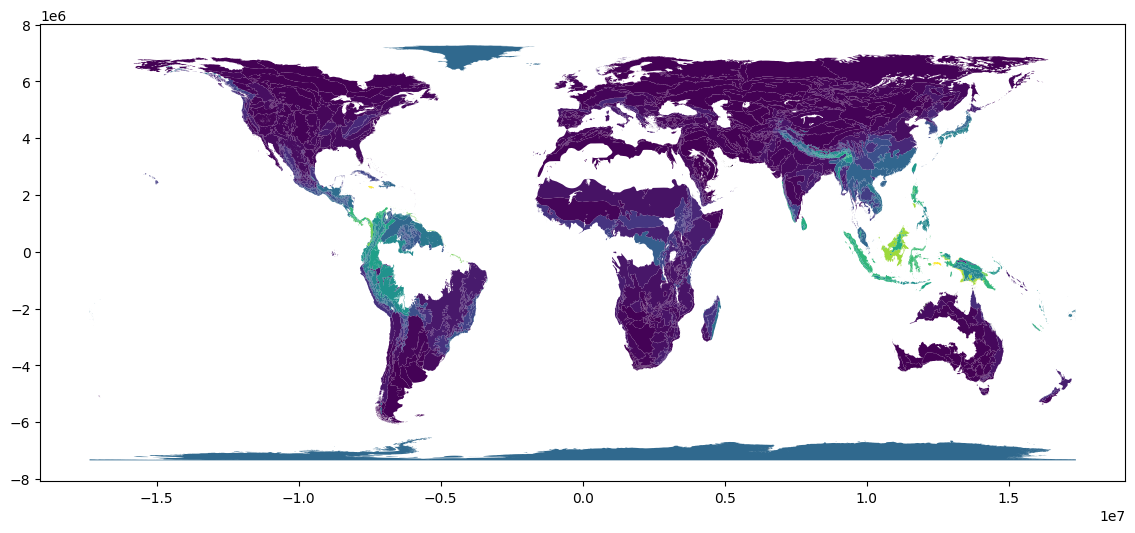

In [14]:
se_er[se_er["flow_name"]=="Barley_rf_ron_rt"].plot(column = "leaf", figsize = (14,8))

In [15]:
se_er_barley = se_er[se_er["flow_name"]=="Barley_rf_ron_rt"]

In [16]:
se_er_barley[se_er_barley["BIOME_NAME"]== "Tundra"]

,OBJECTID,ECO_NAME,BIOME_NUM,BIOME_NAME,REALM,ECO_BIOME_,ECO_ID,geometry,flow_name,leaf,leaf_median,leaf_std,_source_file


<Axes: >

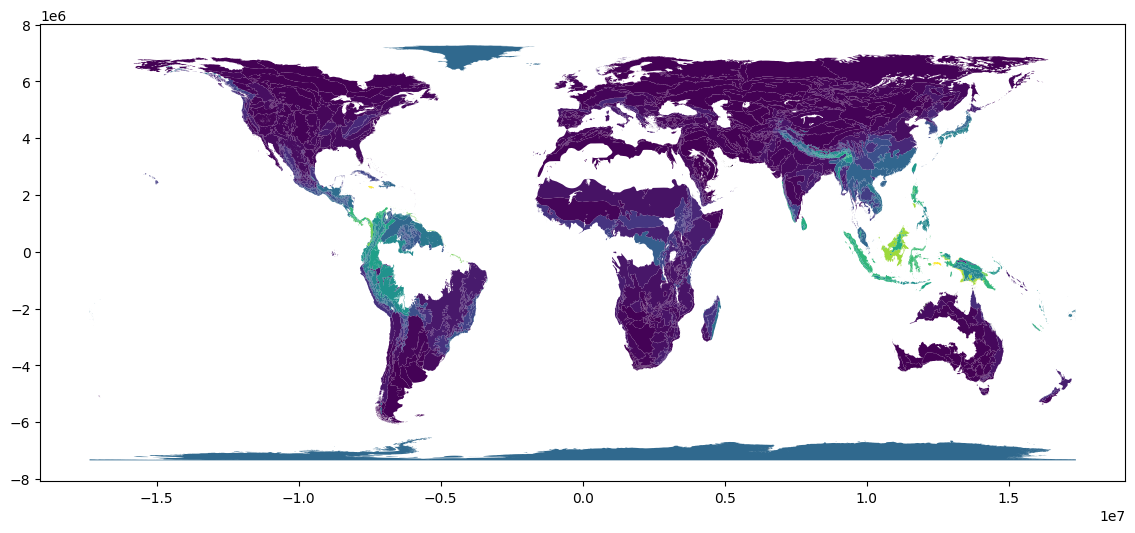

In [17]:
se_er_barley.plot(column = "leaf", figsize = (14,8))

This still plots values for Antarctica, even if it doesn't have rows!

Right — `se_er_barley[se_er_barley["BIOME_NAME"]=="Tundra"]` is genuinely empty, so nothing tagged `"Tundra"` can be what's rendering colored at Antarctica/Greenland. `BIOME_NAME == "Tundra"` only tags a small coastal fringe of Antarctica; the ice-sheet interior that dominates both landmasses isn't vegetated and almost certainly carries a different attribute value there (blank/null biome, `"N/A"`, etc.), not the literal string `"Tundra"`. Identify the real polar polygons by geometry (extreme latitude, using the EPSG:6933 equal-area CRS this layer is already in) instead of guessing a label, and print what they're actually tagged as.

In [ ]:
geom_polar[["ECO_ID", "ECO_NAME", "BIOME_NAME", "REALM"]].drop_duplicates().sort_values("ECO_ID")
# Result (from a real run): every Antarctic and Greenland ecoregion here
# is already labeled BIOME_NAME=="Tundra" -- but so are unrelated
# boreal/taiga ecoregions (Iceland, Yukon, Scandinavia, Siberian taiga)
# that just happen to have a centroid this far north. The latitude-only
# check is too broad to use as a mask on its own -- see below.

So it does have... After 1,000 times deleting them they still have it...

The diagnostic above confirms `BIOME_NAME == "Tundra"` already covers every Antarctic and Greenland ecoregion in this dataset directly by label — the earlier hypothesis that they needed a separate ice-sheet label was wrong. Drop the raw latitude threshold (it over-matches real boreal/taiga ecoregions) and keep just the biome check, plus `REALM == "Antarctica"` as a harmless redundant safety net.

In [ ]:
geom = se_er_gpkg_data[geom_layer]

is_tundra_biome = geom["BIOME_NAME"].astype(str).str.strip().str.lower() == "tundra"
is_antarctic_realm = geom["REALM"].astype(str).str.strip().str.lower() == "antarctica"

no_ag_codes = geom.loc[is_tundra_biome | is_antarctic_realm, "ECO_ID"]

In [20]:
no_ag_codes

0      117
4      404
9      405
15     406
31     196
40     407
41     778
42     408
68     779
69     409
70     410
82     411
94     413
148    118
158    771
169    772
199    415
210    120
245    121
246    122
248    123
307    412
327    711
333    375
335    416
355    418
374    774
434    414
480    126
481    127
488    125
493    775
494    714
522    776
528    777
534    419
543    420
570    128
610    717
611    708
612    780
613    129
641    130
650    131
654    132
676    133
715    781
742    421
743    782
747    134
795    783
798    784
822    381
829    773
831    417
840    119
841    124
Name: ECO_ID, dtype: int64

In [21]:
data = se_er_gpkg_data['se_leaf_ecoregions']

In [22]:
data.head()

,ECO_ID,flow_name,leaf,leaf_median,leaf_std,_source_file
0,135,Barley_rf_ron_rt,NaN,NaN,NaN,se_rate_25km_clipped_Barley_rf_ron_rt.tif
1,785,Barley_rf_ron_rt,5.387818,3.910269,4.863152,se_rate_25km_clipped_Barley_rf_ron_rt.tif
2,807,Barley_rf_ron_rt,2.773447,1.799929,4.479747,se_rate_25km_clipped_Barley_rf_ron_rt.tif
3,722,Barley_rf_ron_rt,NaN,NaN,NaN,se_rate_25km_clipped_Barley_rf_ron_rt.tif
4,723,Barley_rf_ron_rt,NaN,NaN,NaN,se_rate_25km_clipped_Barley_rf_ron_rt.tif


In [23]:
data.loc[data["ECO_ID"].isin(no_ag_codes), ["leaf", "leaf_median", "leaf_std"]] = np.nan

In [24]:
se_er_gpkg_data['se_leaf_ecoregions'] = data

In [25]:
se_er =se_er_gpkg_data[geom_layer].merge(se_er_gpkg_data['se_leaf_ecoregions'], how="left", on = "ECO_ID")

In [26]:
se_er[se_er["ECO_ID"].isin(no_ag_codes)]["leaf"].unique()

array([nan])

<Axes: >

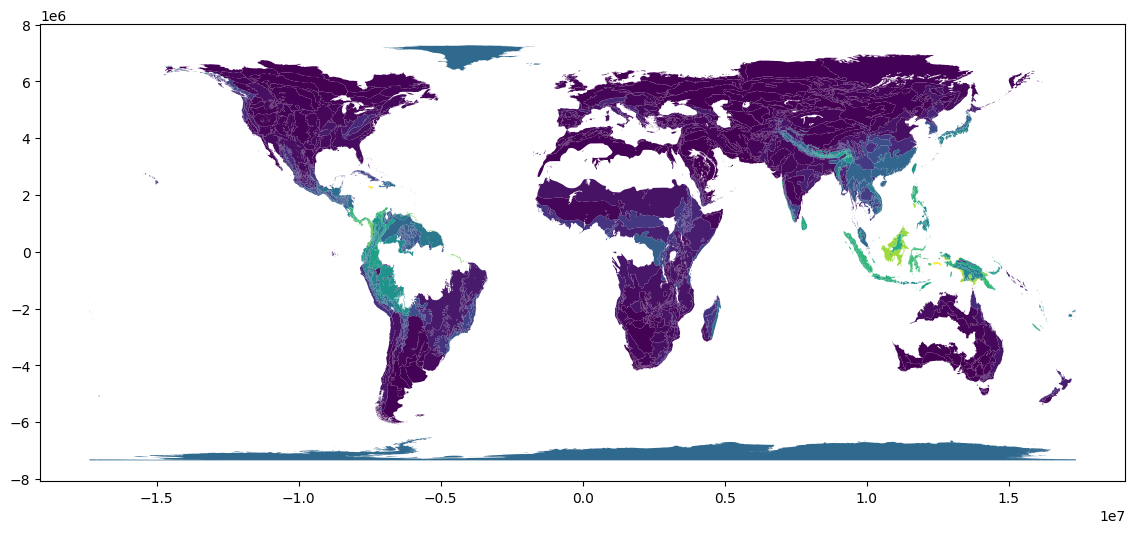

In [27]:
se_er[se_er["flow_name"]=="Barley_rf_ron_rt"].plot(column = "leaf", figsize = (14,8))

In [28]:
se_er_barley = se_er[se_er["flow_name"] == "Barley_rf_ron_rt"]
se_er_barley[se_er_barley["ECO_ID"].isin(no_ag_codes)]["leaf"].unique()

array([nan])

##### Saving

In [29]:
update_gpkg_to_disk(se_er_gpkg_data, soil_er_fp)

Geopackage updated into: ../LEAFs/soil_erosion/se_ecoregions_clipped_2.gpkg


#### df

In [30]:
soil_er_df = pd.read_csv(soil_er_df_fp)

In [31]:
soil_er_df.head()

,ECO_ID,flow_name,metric,value,ECO_NAME,BIOME_NUM,BIOME_NAME,REALM
0,117,se_rate_25km_clipped_Barley_rf_ron_rt,cf_mean,NaN,Adelie Land tundra,11.0,Tundra,Antarctica
1,135,se_rate_25km_clipped_Barley_rf_ron_rt,cf_mean,NaN,Admiralty Islands lowland rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia
2,785,se_rate_25km_clipped_Barley_rf_ron_rt,cf_mean,5.387818,Aegean and Western Turkey sclerophyllous and m...,12.0,"Mediterranean Forests, Woodlands & Scrub",Palearctic
3,807,se_rate_25km_clipped_Barley_rf_ron_rt,cf_mean,2.773447,Afghan Mountains semi-desert,13.0,Deserts & Xeric Shrublands,Palearctic
4,404,se_rate_25km_clipped_Barley_rf_ron_rt,cf_mean,0.868667,Ahklun and Kilbuck Upland Tundra,11.0,Tundra,Nearctic


The cells below (`er_shp` / `soil_er_2` / `df_slice`) read the raw `Ecoregions2017.shp` shapefile and merge it with `soil_er_df` — neither of those has ever had the Tundra/Antarctica NaN mask applied (`soil_er_df` comes straight from `soil_er_df_fp`, which the earlier "Already in a good spot" note explicitly left unmodified). So `df_slice` still has real values over Antarctica/Greenland — that's expected, not a regression. It's kept here for exploration, but use the already-fixed `se_er`/`se_er_barley` (built from the `.gpkg` + `no_ag_codes` above) to check whether the null-out actually worked, not `df_slice`.

In [33]:
er_shp = gpd.read_file("../data/Ecoregions2017/Ecoregions2017.shp")

In [34]:
soil_er_2 = er_shp.merge(soil_er_df, how="left", on="ECO_ID")

In [36]:
soil_er_2.columns

Index(['OBJECTID', 'ECO_NAME_x', 'BIOME_NUM_x', 'BIOME_NAME_x', 'REALM_x',
       'ECO_BIOME_', 'NNH', 'ECO_ID', 'SHAPE_LENG', 'SHAPE_AREA', 'NNH_NAME',
       'COLOR', 'COLOR_BIO', 'COLOR_NNH', 'LICENSE', 'geometry', 'flow_name',
       'metric', 'value', 'ECO_NAME_y', 'BIOME_NUM_y', 'BIOME_NAME_y',
       'REALM_y'],
      dtype='object')

In [37]:
df_slice = soil_er_2[(soil_er_2["flow_name"]=="se_rate_25km_clipped_Barley_rf_ron_rt")&(soil_er_2["metric"]=="cf_mean")]

<Axes: >

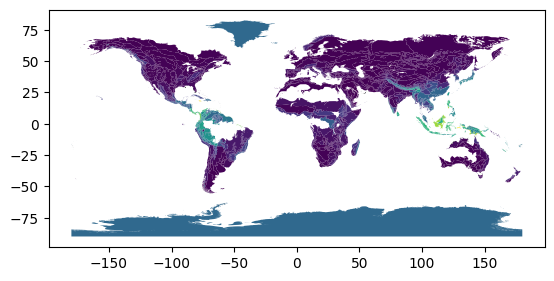

In [38]:
df_slice.plot(column="value")

In [ ]:
import plotly.express as px
import json

def plot_choropleth(gdf, column, id_col=None, title=None, color_continuous_scale="Viridis", simplify_tolerance=0.02):
    """
    Recreate gdf.plot(column=...) using Plotly for interactivity.

    Parameters
    ----------
    gdf : GeoDataFrame
        Must have a valid geometry column.
    column : str
        Column name to color by.
    id_col : str, optional
        Column to use as unique feature ID (defaults to gdf index if None).
    title : str, optional
        Plot title.
    color_continuous_scale : str
        Any Plotly colorscale name (e.g. "Viridis", "Plasma", "RdYlGn").
    simplify_tolerance : float, optional
        Geometry simplification tolerance in degrees, applied after
        reprojecting to EPSG:4326. Full-resolution ecoregion coastlines
        have far more vertices than a browser needs to render a world
        map, and serializing/rendering them all is what made this take
        ~15 minutes; simplifying first cuts vertex count drastically with
        no visible difference at this scale. Set to None/0 to disable.
    """
    gdf = gdf.copy()

    # Plotly needs an id to match rows to geojson features
    if id_col is None:
        gdf["_id"] = gdf.index.astype(str)
        id_col = "_id"
    else:
        gdf[id_col] = gdf[id_col].astype(str)

    # Plotly geojson expects WGS84 (EPSG:4326)
    if gdf.crs is not None and gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(epsg=4326)

    if simplify_tolerance:
        gdf["geometry"] = gdf.geometry.simplify(simplify_tolerance, preserve_topology=True)

    # Only serialize what Plotly actually needs -- every other attribute
    # column (there can be a dozen+ after a merge) bloats the geojson
    # payload for no benefit and was the other big chunk of the slowdown.
    geojson = json.loads(gdf[[id_col, column, "geometry"]].to_json())

    fig = px.choropleth(
        gdf,
        geojson=geojson,
        locations=id_col,
        featureidkey="properties." + id_col,
        color=column,
        color_continuous_scale=color_continuous_scale,
        title=title or column,
    )
    fig.update_geos(fitbounds="locations", visible=False)
    fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
    return fig

In [ ]:
fig = plot_choropleth(se_er_barley, column="leaf", title="Barley_rf_ron_rt (Tundra/Antarctica nulled)")
fig.show()

Already in a good spot. No need to change

#### Subcountry

In [107]:
soil_sc_fp = "../LEAFs/soil_erosion/soil_erosion_subcountry.gpkg"
soil_sc_df_fp = "../LEAFs/soil_erosion/soil_erosion_subcountry.csv"

In [108]:
inspect_gpkg(soil_sc_fp)

geometry_layer: (3422, 4), CRS=EPSG:6933, geom=['MultiPolygon'], geom_type_reported=MultiPolygon
se_leaf_subcountry: TABLE, shape=(273760, 6), columns=['ADM1_CODE', 'flow_name', 'cf', 'cf_median', 'cf_std', '_source_file']
se_leaf_subcountry_metadata: TABLE, shape=(80, 4), columns=['flow_name', 'impact_category', 'unit', 'source_file']


In [109]:
se_sc_gpkg_data = load_gpkg(soil_sc_fp)

In [110]:
se_sc_gpkg_data['se_leaf_subcountry'] = se_sc_gpkg_data['se_leaf_subcountry'].rename(columns = rename_cols)

In [111]:
se_sc_gpkg_data['se_leaf_subcountry'].head()

,ADM1_CODE,flow_name,leaf,leaf_median,leaf_std,_source_file
0,40542,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
1,40543,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
2,40544,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
3,40545,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
4,40546,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif


In [112]:
update_gpkg_to_disk(se_sc_gpkg_data, soil_sc_fp)

Geopackage updated into: ../LEAFs/soil_erosion/soil_erosion_subcountry.gpkg


#### df

In [113]:
soil_sc_df = pd.read_csv(soil_sc_df_fp)

In [114]:
soil_sc_df.head()

,ADM1_CODE,value,metric,flow_name,ADM1_NAME,ADM0_NAME
0,40542,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bubanza,Burundi
1,40543,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Mairie,Burundi
2,40544,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Rural,Burundi
3,40545,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bururi,Burundi
4,40546,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Cankuzo,Burundi


In [115]:
soil_sc_df["metric"] = soil_sc_df["metric"].replace(rename_metrics)

In [116]:
soil_sc_df["metric"].unique()

array(['leaf_mean', 'leaf_median', 'leaf_std'], dtype=object)

In [117]:
soil_sc_df.to_csv(soil_sc_df_fp, index=False)

In [118]:
pd.read_csv(soil_sc_df_fp).head()

,ADM1_CODE,value,metric,flow_name,ADM1_NAME,ADM0_NAME
0,40542,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bubanza,Burundi
1,40543,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Mairie,Burundi
2,40544,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Rural,Burundi
3,40545,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bururi,Burundi
4,40546,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Cankuzo,Burundi


### Country

In [119]:
soil_c_fp = "../LEAFs/soil_erosion/soil_erosion_country.gpkg"
soil_c_df_fp = "../LEAFs/soil_erosion/soil_erosion_country.csv"

In [120]:
inspect_gpkg(soil_c_fp)

geometry_layer: (276, 2), CRS=EPSG:6933, geom=['MultiPolygon'], geom_type_reported=MultiPolygon
se_leaf_country: TABLE, shape=(44160, 6), columns=['ADM0_NAME', 'flow_name', 'cf', 'cf_median', 'cf_std', '_source_file']
se_leaf_country_metadata: TABLE, shape=(160, 4), columns=['flow_name', 'impact_category', 'unit', 'source_file']


In [121]:
se_c_gpkg_data = load_gpkg(soil_c_fp)

In [122]:
se_c_gpkg_data['se_leaf_country'] = se_c_gpkg_data['se_leaf_country'].rename(columns = rename_cols)

In [123]:
se_c_gpkg_data['se_leaf_country'].head()

,ADM0_NAME,flow_name,leaf,leaf_median,leaf_std,_source_file
0,Abyei,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
1,Afghanistan,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
2,Aksai Chin,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
3,Albania,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
4,Algeria,Broadleaf_Deciduous_Boreal_dry,NaN,NaN,NaN,se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif


In [ ]:
update_gpkg_to_disk(se_c_gpkg_data, soil_c_fp)

Geopackage updated into: ../LEAFs/soil_erosion/soil_erosion_subcountry.gpkg


#### df

In [ ]:
soil_sc_df = pd.read_csv(soil_sc_df_fp)

In [ ]:
soil_sc_df.head()

,ADM1_CODE,value,metric,flow_name,ADM1_NAME,ADM0_NAME
0,40542,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bubanza,Burundi
1,40543,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Mairie,Burundi
2,40544,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Rural,Burundi
3,40545,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Bururi,Burundi
4,40546,NaN,cf_mean,Broadleaf_Deciduous_Boreal_dry,Cankuzo,Burundi


In [ ]:
soil_sc_df["metric"] = soil_sc_df["metric"].replace(rename_metrics)

In [ ]:
soil_sc_df["metric"].unique()

array(['leaf_mean', 'leaf_median', 'leaf_std'], dtype=object)

In [ ]:
soil_sc_df.to_csv(soil_sc_df_fp, index=False)

In [ ]:
pd.read_csv(soil_sc_df_fp).head()

,ADM1_CODE,value,metric,flow_name,ADM1_NAME,ADM0_NAME
0,40542,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bubanza,Burundi
1,40543,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Mairie,Burundi
2,40544,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bujumbura Rural,Burundi
3,40545,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Bururi,Burundi
4,40546,NaN,leaf_mean,Broadleaf_Deciduous_Boreal_dry,Cankuzo,Burundi
